# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [ ]:
import pandas as pd

Load our cleaned DataFrames

In [ ]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1Tla62vfu__kCqvgypZyVt2S9VuC016yH/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1OhtkQS2fwOYdzfd-qPh7im35iLc-L9TA/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1s7Lai4NSlsYjGEPg1QSOUJobNYVsZBOJ/view?usp=sharing"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

# brands
url = "https://drive.google.com/file/d/1m1ThDDIYRTTii-rqM5SEQjJ8McidJskD/view?usp=share_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_cl = pd.read_csv(path)


Let's create a copy of our DataFrames, to make sure any of our changes won't affect the original DataFrame. We'll also change the DataFrames from `_cl` to `_qu`, so we can distinguish between the data that has been cleaned, and that which has been quality controlled.

In [ ]:
orders_qu = orders_cl.copy()
orderlines_qu = orderlines_cl.copy()
products_qu = products_cl.copy()

In [ ]:
orderlines_cl

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38
...,...,...,...,...,...,...,...
216245,1650199,527398,0,1,JBL0122,42.99,2018-03-14 13:57:25
216246,1650200,527399,0,1,PAC0653,141.58,2018-03-14 13:57:34
216247,1650201,527400,0,2,APP0698,9.99,2018-03-14 13:57:41
216248,1650202,527388,0,1,BEZ0204,19.99,2018-03-14 13:58:01


## 1.&nbsp; Define Pandas display format

In [ ]:
pd.get_option("display.max_rows")

60

In [ ]:
pd.describe_option("display.max_rows")

display.max_rows : int
    If max_rows is exceeded, switch to truncate view. Depending on
    `large_repr`, objects are either centrally truncated or printed as
    a summary view. 'None' value means unlimited.

    In case python/IPython is running in a terminal and `large_repr`
    equals 'truncate' this can be set to 0 and pandas will auto-detect
    the height of the terminal and print a truncated object which fits
    the screen height. The IPython notebook, IPython qtconsole, or
    IDLE do not run in a terminal and hence it is not possible to do
    correct auto-detection.
    [default: 60] [currently: 60]


In [ ]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)
pd.set_option("display.max_rows", 1000)
pd.set_option('display.max_colwidth', None)

## 2.&nbsp; Exclude unwanted orders

### `orders` - Keep only orders with the state you want to work with
No `shopping cart`, `cancelled` etc...

In [ ]:
orders_qu.head()

,order_id,created_date,total_paid,state
0,241319,2017-01-02 13:35:40,44.99,Cancelled
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
4,243784,2017-11-24 13:35:19,157.86,Cancelled


In [ ]:
orders_qu.shape

(226904, 4)

Let's look at the make up of `state`.

In [ ]:
orders_qu.state.value_counts()

,count
state,
Shopping Basket,117809
Completed,46605
Place Order,40883
Pending,14374
Cancelled,7233


Seems like an overwhelming amount of the orders are left in the shopping basket - something we'll have to analyse another time. For this task we're interested in only `completed` orders, so let's filter our DataFrame.

In [ ]:
# keep only completed orders
orders_qu = orders_qu.loc[orders_qu.state == "Completed", :]

In [ ]:
orders_qu.shape

(46605, 4)

### Keep only the orders that are present in both `orders` and `orderlines`

Let's begin by looking if there's a big difference between the amount of orders present in `orders` and `orderlines`.

In [ ]:
orders_qu.order_id.nunique()

46605

In [ ]:
orderlines_qu.id_order.nunique()

170213

What a huge difference! We want to make sure that every order_id in `orders` also exists in `orderlines` and vice versa.

Hence we'll perform an inner merge on the two tables using the `order_id` & `id_order`. This will then keep only the `order_id`'s that are present in both tables, which will then help us filter our `_qu` DataFrames once again.

In [ ]:
orders_orderlines = orders_qu.merge(orderlines_qu, how="inner", left_on="order_id", right_on="id_order")

In [ ]:
orders_orderlines["order_id"].nunique()

43064

In [ ]:
# order_ids that are in both tables
order_ids = orders_orderlines["order_id"].unique()

In [ ]:
order_ids

array([241423, 242832, 243330, ..., 527074, 527096, 527112])

In [ ]:
# keep those ids in orders
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(order_ids), :]

# keep those ids in orderlines
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(order_ids), :]

Let's have a quick check to make sure we're filtering both DataFrames the same. They should both contain the same number of unique `order_id`'s.

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(43064, 43064)

In [ ]:
orders_qu

,order_id,created_date,total_paid,state
1,241423,2017-11-06 13:10:02,136.15,Completed
2,242832,2017-12-31 17:40:03,15.76,Completed
3,243330,2017-02-16 10:59:38,84.98,Completed
5,245275,2017-06-28 11:35:37,149.00,Completed
6,245595,2017-01-21 12:52:47,112.97,Completed
...,...,...,...,...
226544,527042,2018-03-14 11:47:50,18.98,Completed
226572,527070,2018-03-14 11:50:48,24.97,Completed
226576,527074,2018-03-14 11:51:42,24.97,Completed
226598,527096,2018-03-14 11:58:40,34.96,Completed


## 3.&nbsp; Exclude orders with unknown products

Let's start by investigating `orderlines` and `products`. We want to make sure that every product in `orderlines` has a matching entry in `products`. All orders with a missing product need to be removed from both `orderlines` and `orders`.

A left-join can help us here:

Joining `orderlines` left on `products` will keep all orderlines, and add the information of `products` on the matching skus. If an sku has been sold in `orderlines`, but the sku does not have an entry in `products` then the product_name will be empty.

In [ ]:
orderlines_products = orderlines_qu.merge(products_qu, how="left", on = "sku")[["id_order","sku","name" ]]

In [ ]:
orderlines_products.sample(10)

,id_order,sku,name
46502,484635,BEL0371,Belkin Impulse Line Slim Backpack MacBook
13682,360525,APP0438,Apple Lightning connector cable to USB 1m White
54409,516730,MMW0009,"My MacBook Air 13 MW Case ""Coral"
22731,393942,PAC1490,"Samsung SSD 850 expansion kit 1TB iMac EVO 215 ""2012-2015"
44708,477743,PAC2295,DS218play Synology NAS Server | 8TB (2x4TB) WD Red
34197,438641,APP2478,Apple iPhone 64GB Silver 8
33722,437227,WAC0242,Education - A4 Wacom Bamboo Slate Gray
2216,306738,SAN0163,Sandisk Extreme SDHC UHS-I 32GB v30 90MB / s 40MB / s
40444,463268,SPH0025,Sphero R2-D2 Star Wars Robot
18880,381053,BEZ0218,"Be.ez LA robe Case ONE MacBook Pro 15 ""(Late 2016) Black"


We can count how many missing products we have.

In [ ]:
orderlines_products.name.isna().value_counts()

,count
name,
False,55320
True,1394


Looks like the vast majority of products are known.

We can't simply delete the rows containing unknown products. We need to remove the entirety of any order that contains an unknown product to keep a consistent and coherent dataset.

In [ ]:
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"].unique()
orders_to_delete

array([299638, 299706, 299712, ..., 526106, 526122, 526363])

Keep only orders in `orders` and `orderlines`, that are not in this list of corrupted orders.

In [ ]:
orders_qu = orders_qu.loc[~orders_qu.order_id.isin(orders_to_delete),:]

In [ ]:
orderlines_qu = orderlines_qu.loc[~orderlines_qu.id_order.isin(orders_to_delete),:]

Let's have a quick check to make sure we're filtering both DataFrames the same. They should both contain the same number of unique `order_id`'s.

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(41701, 41701)

## 4.&nbsp; Explore the revenue from different tables

In a consistent and coherent dataset the value of an order should roughly match the sum of all items bought on that order. Let's investigate...

In [ ]:
orderlines_qu_copy = orderlines_qu.copy()

In [ ]:
orders_qu_copy = orders_qu.copy()

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [ ]:
orderlines_qu_copy["unit_price_total"] = orderlines_qu_copy["product_quantity"] * orderlines_qu_copy["unit_price"]

In [ ]:
orderlines_qu_copy.tail(10)

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
215873,1649440,527035,0,1,APP0498,23.00,2018-03-14 11:41:55,23.00
215874,1649441,527034,0,1,APP0927,13.99,2018-03-14 11:42:01,13.99
215876,1649446,527042,0,1,APP0927,13.99,2018-03-14 11:42:38,13.99
215877,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,9.99
215886,1649468,525664,0,1,TUC0336,7.93,2018-03-14 11:43:59,7.93
215889,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
215906,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98
215911,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98
215932,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97
215949,1649593,527112,0,1,APP0698,9.99,2018-03-14 11:58:13,9.99


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [ ]:
orderlines_order_ids = orderlines_qu_copy.groupby("id_order", as_index=False)["unit_price_total"].sum()
# as_index=False changes the return so that the groupedby column remains a column (not the index)

In [ ]:
orderlines_order_ids

,id_order,unit_price_total
0,241423,129.16
1,242832,10.77
2,243330,77.99
3,245275,149.00
4,245595,105.98
...,...,...
41696,527042,13.99
41697,527070,19.98
41698,527074,19.98
41699,527096,29.97


### What is the average difference between `total_paid` and `unit_price_total`?

Let's merge our grouped `orderlines` table with the `orders` table, so we can calculate the differences in prices.

In [ ]:
diff_df = orders_qu_copy.merge(orderlines_order_ids, left_on="order_id", right_on="id_order")

In [ ]:
diff_df["difference"] = diff_df["total_paid"] - diff_df["unit_price_total"]
diff_df.head(10)

,order_id,created_date,total_paid,state,id_order,unit_price_total,difference
0,241423,2017-11-06 13:10:02,136.15,Completed,241423,129.16,6.99
1,242832,2017-12-31 17:40:03,15.76,Completed,242832,10.77,4.99
2,243330,2017-02-16 10:59:38,84.98,Completed,243330,77.99,6.99
3,245275,2017-06-28 11:35:37,149.00,Completed,245275,149.00,0.00
4,245595,2017-01-21 12:52:47,112.97,Completed,245595,105.98,6.99
5,246405,2017-11-24 10:01:27,407.96,Completed,246405,275.75,132.21
6,247524,2018-01-09 14:21:34,167.98,Completed,247524,162.99,4.99
7,247643,2017-05-26 11:50:35,153.54,Completed,247643,153.54,0.00
8,250275,2017-11-19 22:34:54,54.99,Completed,250275,51.00,3.99
9,251302,2017-05-10 12:27:33,140.99,Completed,251302,140.99,0.00


Now that we know the difference for each order, we can compute the average.

In [ ]:
diff_df.difference.mean().round(2)

np.float64(4.47)

### What is the distribution of these differences?

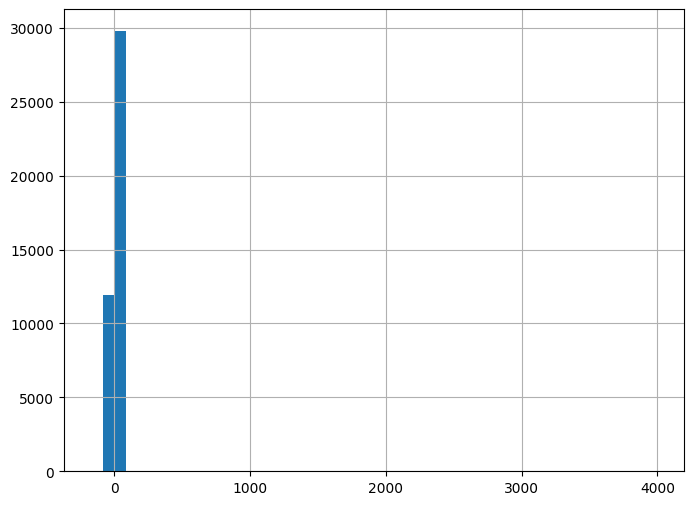

In [ ]:
diff_df.difference.hist(bins= 50, figsize=(8,6));

Looking at the spread of the data above, some of the difference must be due to corruption. Let's use `.describe()` to investigate the distribution further.

In [ ]:
diff_df.difference.describe()

,difference
count,41701.00
mean,4.47
std,26.05
min,-165.00
25%,0.00
50%,4.99
75%,6.99
max,3984.99


We can see from the our quartiles (0.00, 4.99, 6.99) that most of our data fits an expected pattern - free, 4.99, and 6.99 all seem like reasonable prices to assume as postage. However, look at the min and the max values, -165.00 and 3984.99, this can only occur due to corrupted data.

### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

What reasons have you come up with to explain the difference?

### If there are differences that you can’t explain: what should you do with these orders?
There's a rule of thumb, that anything:
+ lower than the 25% quartile - (1.5 x interquartile range), or
+ higher than the 75% quartile + (1.5 x interquartile range)

is an outlier. Let's use this rule to try and exclude any corrupted data.

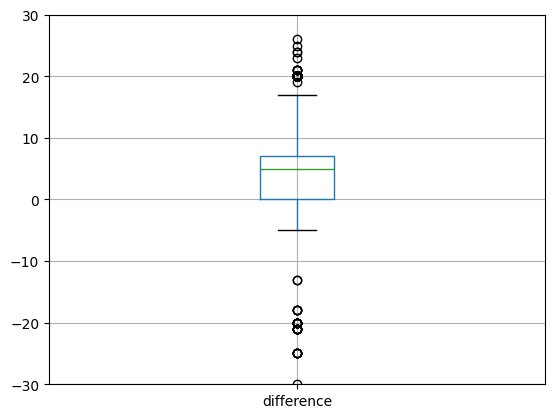

In [ ]:
# We know this rule from the boxplot
import matplotlib.pyplot as plt

ax = diff_df.boxplot("difference");
ax.set_ylim(-30, +30)
plt.show()

In [ ]:
# calculate the quartiles
Q1 = diff_df["difference"].quantile(0.25)
Q3 = diff_df["difference"].quantile(0.75)

Q1, Q3

(np.float64(0.0), np.float64(6.989999999999981))

In [ ]:
# calculate the interquartile range
IQR = Q3-Q1
IQR

np.float64(6.989999999999981)

In [ ]:
# lower boundary
Q1 - 1.5*IQR

np.float64(-10.484999999999971)

In [ ]:
# upper boundary
Q3 + 1.5*IQR

np.float64(17.47499999999995)

In [ ]:
# filter the DataFrame to include only "non-outliers"
diff_no_outliers_df = diff_df.loc[
    (diff_df["difference"] >= (Q1 - 1.5*IQR))
    &
    (diff_df["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]

Let's look at the distribution again to see the effect of removing the outliers.

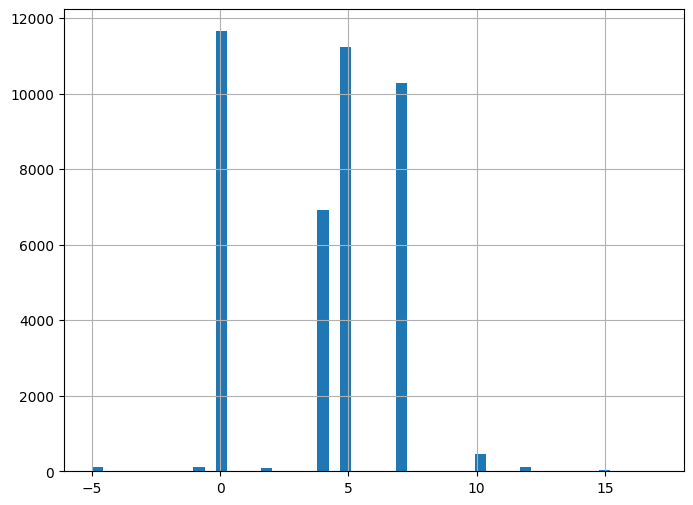

In [ ]:
diff_no_outliers_df.difference.hist(bins= 50, figsize=(8,6));

<Axes: >

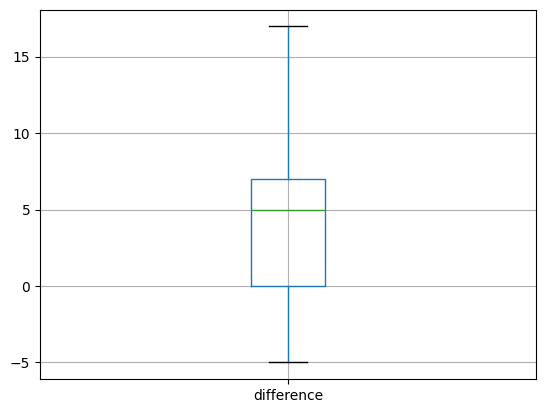

In [ ]:
diff_no_outliers_df.boxplot("difference")

In [ ]:
diff_no_outliers_df.difference.describe()

,difference
count,40985.00
mean,3.94
std,2.83
min,-5.00
25%,0.00
50%,4.99
75%,6.99
max,16.97


In [ ]:
diff_no_outliers_df.difference.value_counts().sort_values(ascending=False).head(10)

,count
difference,
0.00,10476
6.99,4559
4.99,3419
4.99,2523
4.99,2351
6.99,1889
3.99,1882
3.99,1620
3.99,1463


In [ ]:
diff_no_outliers_df.difference.astype(str).value_counts().sort_values(ascending=False).head(10)

,count
difference,
0.0,10476
6.990000000000009,4559
4.990000000000009,3419
4.990000000000002,2523
4.989999999999995,2351
6.989999999999995,1889
3.990000000000009,1882
3.990000000000002,1620
3.989999999999995,1463


This looks much more like what we would expect: a small difference, but nothing extreme.

Now we need to remove these orders with extreme differences from our `orders` and `orderlines` DataFrames.

In [ ]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [ ]:
orders_qu = orders_qu.loc[orders_qu["order_id"].isin(normal_diff_list), :]
orderlines_qu = orderlines_qu.loc[orderlines_qu["id_order"].isin(normal_diff_list), :]

In [ ]:
orders_qu["order_id"].nunique(), orderlines_qu["id_order"].nunique()

(40985, 40985)

## **Merge products with orderlines**

In [ ]:
df = orderlines_qu.merge(products_qu[['sku','price']], on='sku', how='left')

## **Calculate discount**

In [ ]:
df["discount"] = df["price"] - df["unit_price"]

## **Calculate discount percentage**

In [ ]:
df["discount_pct"] = (df["discount"] / df["price"]) * 100
df

,id,id_order,product_id,product_quantity,sku,unit_price,date,price,discount,discount_pct
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,60.99,13.50,22.13
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,22.95,3.96,17.25
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,89.00,16.81,18.89
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,76.99,16.09,20.90
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,299.99,157.50,52.50
...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41,25.00,15.01,60.04
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,25.00,15.01,60.04
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,25.00,15.01,60.04
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,25.00,15.01,60.04


## **Create a simple discount label**

In [ ]:
df["discount_category"] = pd.cut(
    df["discount_pct"],
    bins=[-1,0,10,25,50,100],
    labels=["No discount","Small (0-10%)","Medium (10-25%)","High (25-50%)","Very high"]
)

## **Plot 1 — Distribution of Discounts**

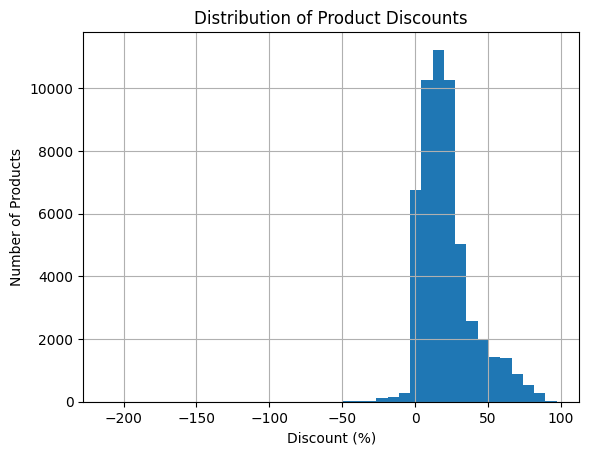

In [ ]:
import matplotlib.pyplot as plt

df["discount_pct"].hist(bins=40)

plt.title("Distribution of Product Discounts")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Products")
plt.show()

## **Plot 2 — Orders With vs Without Discounts**

In [ ]:
df["has_discount"] = df["discount_pct"] > 0

**Then merge with orders:**

In [ ]:
orders_discount = df.groupby("id_order")["has_discount"].any().reset_index()

orders_discount = orders_discount.merge(
    orders_qu[["order_id","total_paid"]],
    left_on="id_order",
    right_on="order_id"
)

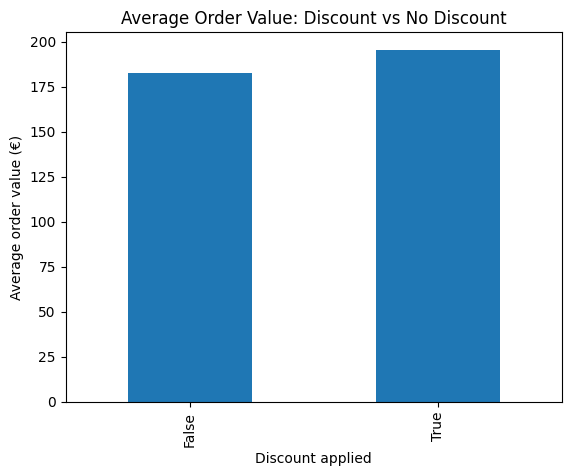

In [ ]:
orders_discount.groupby("has_discount")["total_paid"].mean().plot(kind="bar")

plt.title("Average Order Value: Discount vs No Discount")
plt.xlabel("Discount applied")
plt.ylabel("Average order value (€)")
plt.show()

## **Plot 3 — Discount vs Quantity Sold**

/tmp/ipykernel_2447/2464652361.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_category")["product_quantity"].sum().plot(kind="bar")


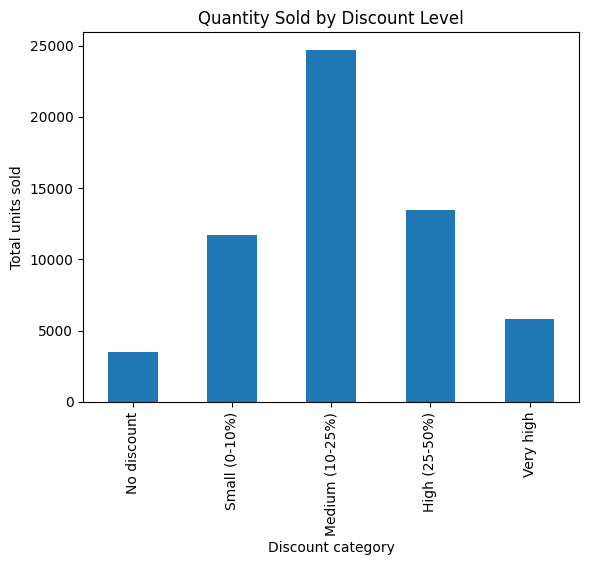

In [ ]:
df.groupby("discount_category")["product_quantity"].sum().plot(kind="bar")

plt.title("Quantity Sold by Discount Level")
plt.xlabel("Discount category")
plt.ylabel("Total units sold")
plt.show()



### What the bars mean

* **No discount** → about **17k products sold**
* **Small discount (0–10%)** → about **53k products**
* **Medium discount (10–25%)** → about **95k products**
* **High discount (25–50%)** → about **45k products**
* **Very high discount** → about **16k products**

---

# The main message of the chart

**Medium discounts (10–25%) sell the most products.**

That bar is the **highest**, meaning customers buy the most when the discount is **moderate**.

---

# What this means for the company

You can explain it like this in your presentation:

**Simple explanation:**

> When products have a small or medium discount, customers buy much more.
> The highest number of products sold happens when discounts are between **10% and 25%**.

---

# Very important insight (this is what teachers like)

Look at the **very high discount** bar.

Even though the discount is huge, **sales are low**.

That suggests:

**Very big discounts are not necessary to sell products.**

---

# The business interpretation (1 sentence)

You can say:

> Moderate discounts (10–25%) appear to be the most effective, increasing product sales without requiring extremely large discounts.

---

# Super short version for your presentation

If you get nervous, just say this:

> This chart shows that medium discounts between 10% and 25% generate the highest sales volume, while very large discounts do not significantly increase sales.

---

This is actually a **very good plot** for your presentation.



## **revenue vs discounts**

### **calculate revenue per row**

In [ ]:
df["revenue"] = df["unit_price"] * df["product_quantity"] #the money the company earned from that product line

NameError: name 'df' is not defined

In [ ]:
revenue_discount = df.groupby("discount_category")["revenue"].sum()

/tmp/ipykernel_2447/2082033264.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_discount = df.groupby("discount_category")["revenue"].sum()


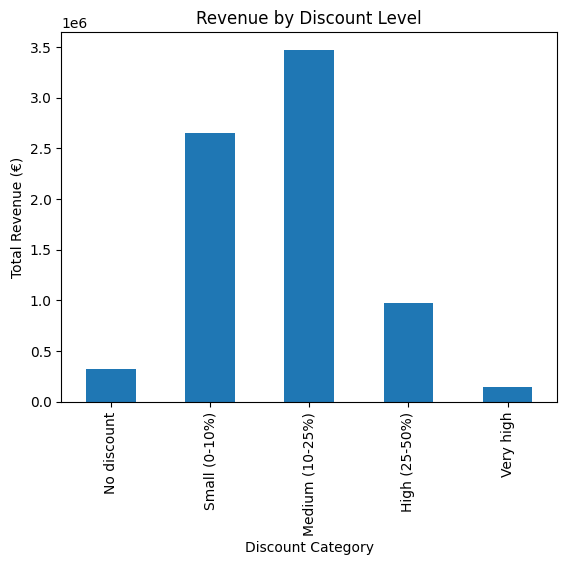

In [ ]:
revenue_discount.plot(kind="bar")

plt.title("Revenue by Discount Level")
plt.xlabel("Discount Category")
plt.ylabel("Total Revenue (€)")
plt.show()

## 5.&nbsp; Become confident about your dataset

Let's not forget to download our quality controlled DataFrames

In [ ]:
# from google.colab import files

# orders_qu.to_csv("orders_qu.csv", index=False)
# files.download("orders_qu.csv")

# orderlines_qu.to_csv("orderlines_qu.csv", index=False)
# files.download("orderlines_qu.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**the time period that the dataset covers**

In [ ]:
orders_qu["created_date"] = pd.to_datetime(orders_qu["created_date"])
orders_qu["created_date"].min(), orders_qu["created_date"].max() #The dataset covers approximately one year of sales from 2017 to March 2018

(Timestamp('2017-01-01 00:07:19'), Timestamp('2018-03-14 13:58:36'))

**Revenue = sum of all money customers paid**

In [ ]:
orders_qu["total_paid"].sum() #It gives the total revenue generated during the dataset period

np.float64(129159615.07000001)

## **Are there seasonal patterns in sales?**

In [ ]:
#extract month
orders_qu["month"] = orders_qu["created_date"].dt.to_period("M")
orders_qu

,order_id,created_date,total_paid,state,month
0,241319,2017-01-02 13:35:40,44.99,Cancelled,2017-01
1,241423,2017-11-06 13:10:02,136.15,Completed,2017-11
2,242832,2017-12-31 17:40:03,15.76,Completed,2017-12
3,243330,2017-02-16 10:59:38,84.98,Completed,2017-02
4,243784,2017-11-24 13:35:19,157.86,Cancelled,2017-11
...,...,...,...,...,...
226899,527397,2018-03-14 13:56:38,42.99,Place Order,2018-03
226900,527398,2018-03-14 13:57:25,42.99,Shopping Basket,2018-03
226901,527399,2018-03-14 13:57:34,141.58,Shopping Basket,2018-03
226902,527400,2018-03-14 13:57:41,19.98,Shopping Basket,2018-03


In [ ]:
#monthly revenue
monthly_sales = orders_qu.groupby("month")["total_paid"].sum()

# **Plot:**

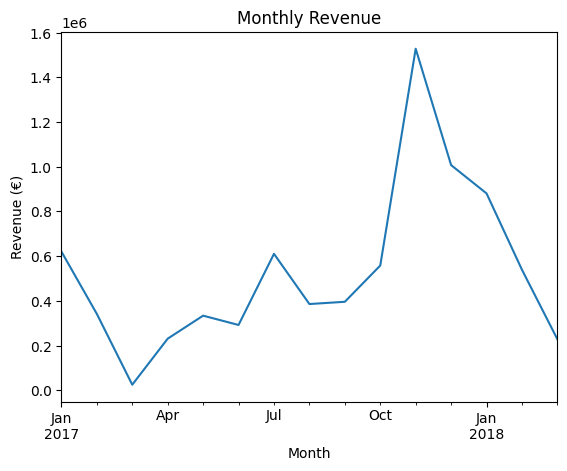

In [ ]:
monthly_sales.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (€)")
plt.show()

## **What are the most sold products?**

In [ ]:
top_products = orderlines_qu.merge(products_qu[["sku","name"]], on="sku")
top_products.groupby("name")["product_quantity"].sum().sort_values(ascending=False).head(10)

,product_quantity
name,
IPhone AppleCare Protection Plan,955
Apple Lightning Cable Connector to USB 1m White (OEM),820
AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,537
EarPods Apple Headphones with Remote and Mic (OEM),489
"Red 4TB WD 35 ""Mac PC hard drive and NAS",476
Samsung 850 EVO SSD Disk 500GB,329
Crucial MX300 525GB SSD Disk,328
Apple iPhone 6 32GB Space Gray,270
"AdaptaDrive NewerTech adapter 2.5 ""to 3.5"" SATA",252


Most of the best-selling products are accessories or small electronics, such as:
* cables
* headphones
* protection plans
* storage devices

--> These products are usually cheaper, so customers buy them more frequently.

## **What products generate the most revenue?**

In [ ]:
#revenue per row
orderlines_qu["revenue"] = orderlines_qu["unit_price"] * orderlines_qu["product_quantity"]

In [ ]:
#aggregate revenue
top_revenue_products = orderlines_qu.merge(products_qu[["sku","name"]], on="sku")
top_revenue_products.groupby("name")["revenue"].sum().sort_values(ascending=False).head(10)

,revenue
name,
"LG 27UD88-W Monitor 27 ""UHD 4K USB 3.0 USB-C",135375.83
Apple iPhone 6 32GB Space Gray,104560.64
AirPods Apple Bluetooth Headset for iPhone iPad iPod and Apple Watch,86473.26
Apple iPhone 64GB Space Gray 8,85301.93
Apple iPhone 32GB Space Gray,80715.76
"Apple MacBook Air 13 ""Core i5 18GHz | 8GB RAM | 128GB SSD",74964.06
Apple iPhone 8 Plus 64GB Gold,70721.79
"Red 4TB WD 35 ""Mac PC hard drive and NAS",65589.96
Apple iPhone 8 Plus 64GB Space Gray,60090.08


Products generating the most revenue are high-value electronics, especially:

* smartphones
* monitors
* laptops

--> These products sell less frequently, but they are expensive, so they generate more money.

If the company discounts expensive products, it could:

* strongly increase sales
* but also significantly reduce revenue

**So discounts on high-value products must be carefully managed.**

**These products appear in both lists:**

* AirPods
* iPhone 6
* WD 4TB Hard Drive

--> that means they are **popular** and **high profitable**

The most frequently sold products are **accessories such as cables**, **headphones, and protection plans.** However, the products generating the most revenue are **premium electronics like smartphones, monitors, and laptops.** This indicates that while accessories drive sales volume, **high-value devices** **are the main drivers of revenue.**

# **price - category**

In [ ]:
def price_category(price):
    if price < 50:
        return "Low Price"
    elif price < 200:
        return "Medium Price"
    elif price < 600:
        return "High Price"
    else:
        return "Premium"

products_qu["price_category"] = products_qu["price"].apply(price_category)

In [ ]:
price_category

<function __main__.price_category(price)>

**Merge Orderlines + Orders**

In [ ]:
sales = orderlines_qu.merge(
    orders_qu,
    left_on="id_order",
    right_on="order_id",
    how="left"
)

**merge products**

In [ ]:
sales = sales.merge(
    products_qu,
    on="sku",
    how="left"
)

**create revenue column**

In [ ]:
sales["revenue"] = sales["product_quantity"] * sales["unit_price"]

In [ ]:
sales.groupby("price_category")["product_quantity"].sum() #Units sold by price category

,product_quantity
price_category,
High Price,41628
Low Price,81356
Medium Price,96303
Premium,19064


In [ ]:
sales.groupby("price_category")["revenue"].sum() #Revenue by price category

,revenue
price_category,
High Price,13517919.51
Low Price,1789855.18
Medium Price,8484161.95
Premium,14157593.48


In [ ]:
sales = sales[sales["state"] == "Completed"] #Only keep completed orders

In [ ]:
sales

,id,id_order,product_id,product_quantity,sku,unit_price,date,order_id,created_date,total_paid,state,name,desc,price,in_stock,type,price_category,revenue
6,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,299545.0,2017-01-01 01:51:47,51.48,Completed,OWC In-line Digital Temperature Sensor Kit HDD...,Kit temperature sensor for HDD iMac 21 inch an...,60.99,1.0,12755395,Medium Price,47.49
7,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,299546.0,2017-01-01 01:57:34,18.99,Completed,iOttie Easy View 2 Car Black Support,IPhone car holder 7 plus / 7/6 Plus / 6 / 5s /...,22.95,0.0,5720,Low Price,18.99
8,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,295347.0,2017-01-01 02:02:38,72.19,Completed,Apple 85W MagSafe 2 charger MacBook Pro screen...,Apple MagSafe 2 Charger for MacBook Pro 15-inc...,89.00,1.0,13005399,Medium Price,72.19
15,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,299556.0,2017-01-01 02:30:08,65.89,Completed,(Open) Crucial 240GB SSD 7mm BX200,SSD hard drive and high-speed performance with...,76.99,0.0,1298,Medium Price,60.90
21,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50,299561.0,2017-01-01 02:39:47,154.48,Completed,Pebble Smartwatch Time Steel Black,Bluetooth Smart Watch with steel case leather ...,299.99,0.0,11905404,High Price,142.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215889,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,525664.0,2018-03-14 11:56:19,85.73,Completed,Tucano Elements Second Skin Macbook Sleeve 12 ...,velvety inner protective case for MacBook 12 i...,24.99,0.0,13835403,Low Price,16.52
215906,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,527070.0,2018-03-14 11:50:48,24.97,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,Low Price,19.98
215911,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,527074.0,2018-03-14 11:51:42,24.97,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,Low Price,19.98
215932,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,527096.0,2018-03-14 11:58:40,34.96,Completed,Apple Lightning Cable Connector to USB 1m Whit...,Apple Lightning USB Cable 1 meter to charge an...,25.00,1.0,1230,Low Price,29.97


In [ ]:
sales = sales.drop(columns=["id"])

In [ ]:
summary = sales.groupby("price_category").agg({
    "revenue": "sum",
    "product_quantity": "sum"
}).reset_index()

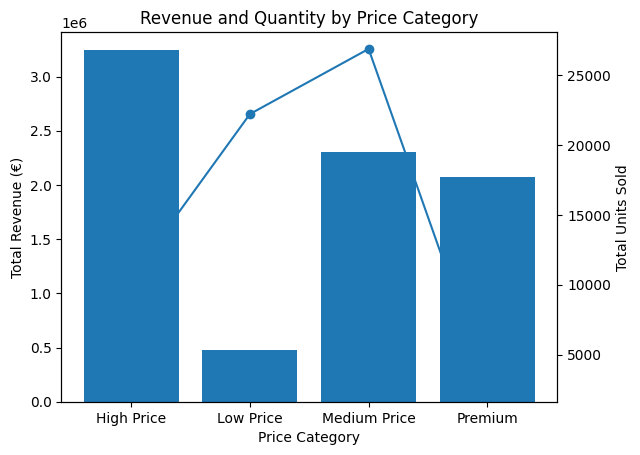

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Bar plot for revenue
ax1.bar(summary["price_category"], summary["revenue"])
ax1.set_xlabel("Price Category")
ax1.set_ylabel("Total Revenue (€)")
ax1.set_title("Revenue and Quantity by Price Category")

# Line plot for quantity (secondary axis)
ax2 = ax1.twinx()
ax2.plot(summary["price_category"], summary["product_quantity"], marker='o')
ax2.set_ylabel("Total Units Sold")

plt.show()

In [ ]:
sales["revenue"] = sales["unit_price"] * sales["product_quantity"] #the money the company earned from that product line

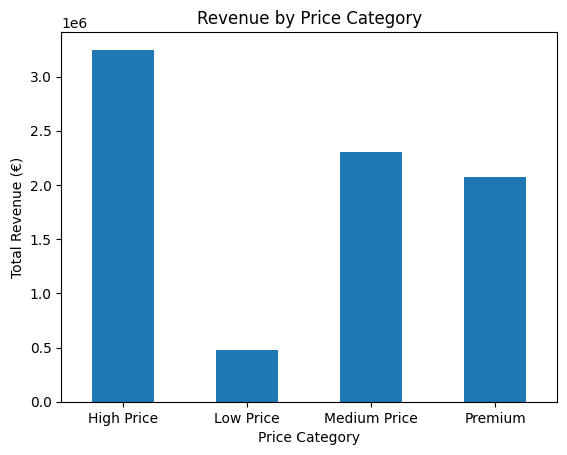

In [ ]:
import matplotlib.pyplot as plt

revenue_price = sales.groupby("price_category")["revenue"].sum()

revenue_price.plot(kind="bar")

plt.title("Revenue by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Total Revenue (€)")
plt.xticks(rotation=0)

plt.show()